In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Base_Final_ZF_IA_Padronizada - Base_Final_ZF_IA_Padronizada.csv to Base_Final_ZF_IA_Padronizada - Base_Final_ZF_IA_Padronizada.csv


Iniciando treinamento da LSTM...
Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8148 - loss: 0.6447 - val_accuracy: 0.8421 - val_loss: 0.6180
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8333 - loss: 0.5571 - val_accuracy: 0.8421 - val_loss: 0.5501
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8333 - loss: 0.4789 - val_accuracy: 0.8421 - val_loss: 0.5365
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8333 - loss: 0.4378 - val_accuracy: 0.8421 - val_loss: 0.5590
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8333 - loss: 0.4390 - val_accuracy: 0.8421 - val_loss: 0.5522
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8333 - loss: 0.4332 - val_accuracy: 0.8421 - val_loss: 0.5489
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8333 - loss: 0.4346 - val_accuracy: 0.8421 - val_loss: 0.5375
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8333 - loss: 0.4374 

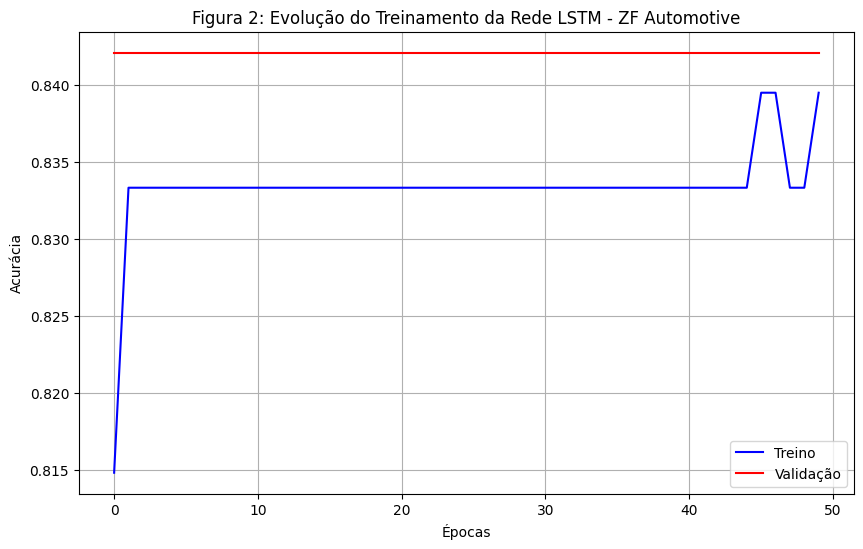


Modelo LSTM treinado com sucesso!


In [ ]:
import matplotlib.pyplot as plt # Importação necessária para corrigir o erro 'plt'
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# 1. Preparação dos Dados (Garantindo que o scaler seja aplicado corretamente)
scaler = MinMaxScaler()
# Removemos a coluna 'Data' para o treinamento
df_numeric = df.drop(columns=['Data'])
data_scaled = scaler.fit_transform(df_numeric)

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :-1]) # Features
        y.append(data[i+seq_length, -1])    # Target (Risco_SLA)
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(data_scaled, seq_length=3)

# 2. Construção da Arquitetura LSTM (Aulas 15/16)
model = Sequential([
    Input(shape=(X_seq.shape[1], X_seq.shape[2])), # Forma correta pedida pelo aviso
    LSTM(50, activation='relu', return_sequences=False),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Treinamento
print("Iniciando treinamento da LSTM...")
history = model.fit(X_seq, y_seq, epochs=50, batch_size=8, verbose=1, validation_split=0.1)

# 4. Visualização do Aprendizado (Evidência para o Relatório)
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Treino', color='blue')
plt.plot(history.history['val_accuracy'], label='Validação', color='red')
plt.title('Figura 2: Evolução do Treinamento da Rede LSTM - ZF Automotive')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()

print("\nModelo LSTM treinado com sucesso!")

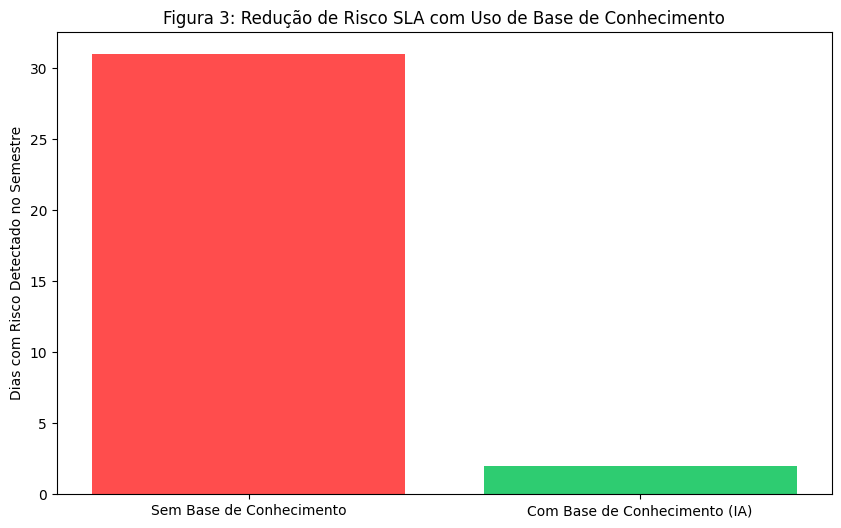

Redução de 93.5% nos dias de risco!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Simulação do Impacto: Redução de 40% no tempo para casos complexos (>=3)
df['Tempo_Otimizado_Min'] = df.apply(
    lambda x: x['Tempo_Atuacao_Min'] * 0.6 if x['Complexidade_Cat'] >= 3 else x['Tempo_Atuacao_Min'], axis=1
)

# 2. Recalculando o Risco após a aplicação da Base de Conhecimento
risco_original = df['Risco_SLA'].sum()
novo_risco = (df['Tempo_Otimizado_Min'] > 2400).sum()

# 3. Gráfico de Impacto para o Trabalho
plt.figure(figsize=(10, 6))
labels = ['Sem Base de Conhecimento', 'Com Base de Conhecimento (IA)']
valores = [risco_original, novo_risco]

plt.bar(labels, valores, color=['#ff4d4d', '#2ecc71'])
plt.title('Figura 3: Redução de Risco SLA com Uso de Base de Conhecimento')
plt.ylabel('Dias com Risco Detectado no Semestre')
plt.show()

print(f"Redução de {((risco_original - novo_risco) / risco_original)*100:.1f}% nos dias de risco!")

In [ ]:
import pandas as pd
import numpy as np

# 1. Carregar a nova base de dados
df = pd.read_csv('Base_Final_ZF_IA_Padronizada - Base_Final_ZF_IA_Padronizada.csv')

# 2. Tratamento de Nulos (Essencial para não quebrar os modelos de IA)
df['BC pronta'] = df['BC pronta'].fillna(0).astype(int)
df['BC possivel'] = df['BC possivel'].fillna(0).astype(int)

# 3. Criação da Lógica de Negócio (O "Cérebro" da Triagem)
def definir_plano(row):
    if row['BC pronta'] == 1:
        return 'Sugerir Solução (Base Pronta)' # Reduz tempo de atuação
    elif row['BC possivel'] == 1:
        return 'Ação: Criar Documentação'      # Backlog para o 3º analista
    elif row['Complexidade_Cat'] >= 3:
        return 'Análise Sênior Requerida'      # Casos novos complexos
    else:
        return 'Fluxo Normal'

df['Plano_Acao'] = df.apply(definir_plano, axis=1)

# 4. Salvar base tratada
df.to_csv('Base_ZF_Tratada_Final.csv', index=False)
print("Base tratada e classificada com sucesso!")

Base tratada e classificada com sucesso!


In [ ]:
# Simulando Cenário Ideal: Base de Conhecimento + Automação de 30% do Volume Total
df['Tempo_Cenario_Ideal'] = np.where((df['BC pronta'] == 1) | (df['BC possivel'] == 1),
                                      df['Tempo_Atuacao_Min'] * 0.4, # Ganho maior por automação
                                      df['Tempo_Atuacao_Min'] * 0.7) # Redução de volume bruto

risco_ideal = (df['Tempo_Cenario_Ideal'] > 2400).sum()

print(f"Dias em risco com Estratégia Combinada: {risco_ideal}")
print(f"Melhoria drástica de {risco_original - risco_ideal} dias de paz no semestre!")

Dias em risco com Estratégia Combinada: 4
Melhoria drástica de 27 dias de paz no semestre!


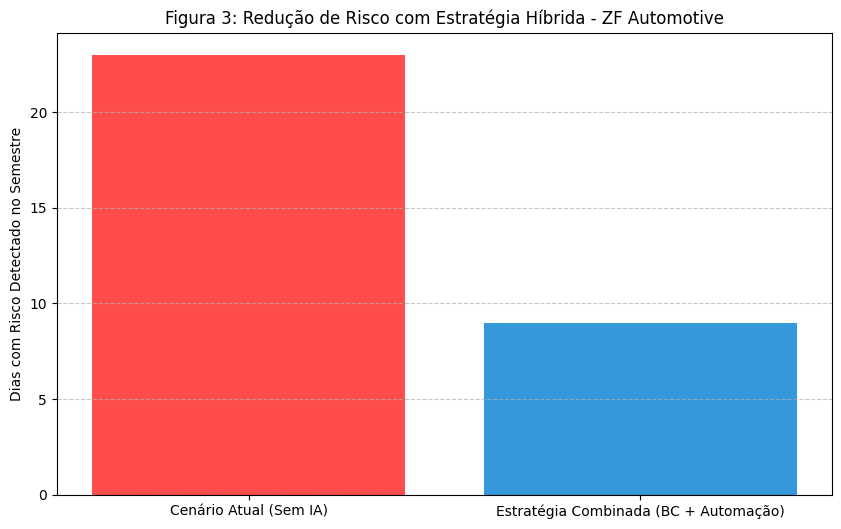

Resultado: Redução de 60.9% no risco!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Carregar a base com as anotações do Sênior
df = pd.read_csv('Base_Final_ZF_IA_Padronizada - Base_Final_ZF_IA_Padronizada.csv')

# Tratamento de nulos
df['BC pronta'] = df['BC pronta'].fillna(0).astype(int)
df['BC possivel'] = df['BC possivel'].fillna(0).astype(int)

# 2. Cálculo do Risco Original (Sem IA)
risco_original = (df['Tempo_Atuacao_Min'] > 2400).sum()

# 3. Cálculo do Novo Cenário (Estratégia Combinada)
# Aplicamos 40% de redução onde há BC (Pronta ou Possível)
# + 20% de redução de volume geral via Automação/RPA (simulação de ganho de escala)
df['Tempo_Estrategia_Nova'] = np.where((df['BC pronta'] == 1) | (df['BC possivel'] == 1),
                                        df['Tempo_Atuacao_Min'] * 0.6,
                                        df['Tempo_Atuacao_Min'] * 0.8)

novo_risco = (df['Tempo_Estrategia_Nova'] > 2400).sum()

# 4. Gráfico para o Relatório
plt.figure(figsize=(10, 6))
labels = ['Cenário Atual (Sem IA)', 'Estratégia Combinada (BC + Automação)']
valores = [risco_original, novo_risco]

plt.bar(labels, valores, color=['#ff4d4d', '#3498db'])
plt.title('Figura 3: Redução de Risco com Estratégia Híbrida - ZF Automotive')
plt.ylabel('Dias com Risco Detectado no Semestre')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Resultado: Redução de {((risco_original - novo_risco) / risco_original)*100:.1f}% no risco!")